# Null and Duplicate Data Cleaning
**Course:** Data Analysis and Indicators  
**Author:** Alan Jesús Hernández Soto
**Date:** February 2026

## Objective
Review missing and duplicate data, then apply simple cleaning rules when needed.

## Datasets
- **Source:** Class material
- **Files:** videogames_data.csv, houses_data.csv, data/videogames_data_dup.csv

## Analysis

### 1. Missing Data

Missing values can bias results, reduce model accuracy, and weaken data quality.

#### 1.1 Classification

- **MCAR:** Missing completely at random.
- **MAR:** Missing at random.
- **MNAR:** Missing not at random.

#### 1.2 Treatment

Treatment depends on the amount and meaning of the missing data.
- Use imputation for small or manageable gaps.
- Remove records or variables when missingness is too large or not useful.

### 2. Guided Example: Game On! Missing Data

A short exercise on identifying, removing, and imputing missing values in a videogame customer dataset.

### 2. Guided Example: Game On!

This section analyzes missing values in a small videogame customer survey.

**Records:** 188 customers.

**Variables:** id, age, gender, survey, satisfaction, purchase, and items.

**Missing data analysis**.

In [ ]:
import pandas as pd

games=pd.read_csv('videogames_data.csv')
def null_percentage(dataframe):
    return dataframe.isnull().sum()/len(dataframe)

In [846]:
games.head()

,id,edad,genero,encuesta,satisfaccion,compra,articulos
0,1,25.5,Hombre,1,2.0,206.3,4.0
1,2,40.0,Hombre,1,5.0,297.9,NaN
2,3,30.0,Hombre,1,3.0,273.4,NaN
3,4,29.5,Mujer,1,5.0,327.6,NaN
4,5,35.0,Hombre,0,NaN,509.7,4.0


In [ ]:
# Get the number of non-null values and the data type
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            188 non-null    int64  
 1   edad          175 non-null    float64
 2   genero        164 non-null    object 
 3   encuesta      188 non-null    int64  
 4   satisfaccion  145 non-null    float64
 5   compra        150 non-null    float64
 6   articulos     114 non-null    float64
dtypes: float64(4), int64(2), object(1)
memory usage: 10.4+ KB


Number of null values

In [848]:
games.isnull().sum()

id               0
edad            13
genero          24
encuesta         0
satisfaccion    43
compra          38
articulos       74
dtype: int64

Number of non-null values

In [849]:
games.notnull().sum()

id              188
edad            175
genero          164
encuesta        188
satisfaccion    145
compra          150
articulos       114
dtype: int64

Percentage of null values

In [850]:
games.isnull().sum()/len(games)

id              0.000000
edad            0.069149
genero          0.127660
encuesta        0.000000
satisfaccion    0.228723
compra          0.202128
articulos       0.393617
dtype: float64

- *Age:* 13 of 188 records (6.9%).
- *Gender:* 24 of 188 records (12.7%).
- *Satisfaction:* 43 of 188 records (22.9%).
- *Purchase:* 38 of 188 records (20.2%).
- *Items:* 74 of 188 records (39.3%).

The columns of interest are items and satisfaction.

**Removing missing data**

Missing satisfaction values come from customers who did not answer the survey. Since the analysis focuses on respondents, those rows are removed.

**Note:** This choice can introduce selection bias.

In [851]:
games_M_encuesta=games[games['encuesta']==1]

In [852]:
games_M_encuesta = games_M_encuesta.drop(columns=['articulos'])

In [853]:
games_M_encuesta['satisfaccion'].isnull().groupby(games_M_encuesta['encuesta']).sum()

encuesta
1    0
Name: satisfaccion, dtype: int64

Check missing values again

In [854]:
games_M_encuesta.isnull().sum()

id               0
edad            11
genero          18
encuesta         0
satisfaccion     0
compra          13
dtype: int64

In [ ]:
null_percentage(games_M_encuesta)

id              0.000000
edad            0.058511
genero          0.095745
encuesta        0.000000
satisfaccion    0.000000
compra          0.069149
dtype: float64

**Mode imputation**

Gender is a categorical variable, so missing values are filled with the mode.

In [856]:
games_M_encuesta['genero'].mode()[0]

'Hombre'

Fill the gender variable

In [857]:
games_M_encuesta['genero'] = games_M_encuesta['genero'].fillna(games_M_encuesta['genero'].mode()[0])

Check the null percentage

In [ ]:
null_percentage(games_M_encuesta)

id              0.000000
edad            0.075862
genero          0.000000
encuesta        0.000000
satisfaccion    0.000000
compra          0.089655
dtype: float64

**Median imputation**

Age is imputed with the median after checking its distribution.

What distribution does it have?

<Axes: >

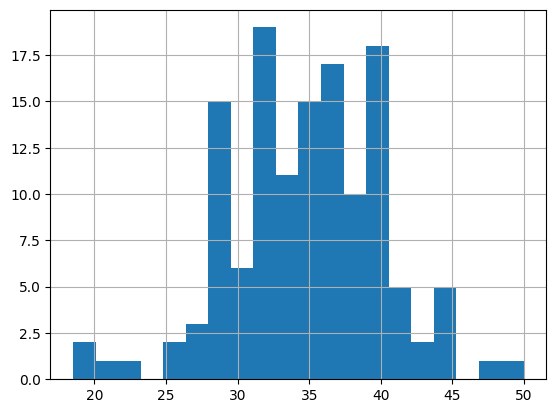

In [859]:
games_M_encuesta['edad'].hist(bins=20)

Because the distribution is close to normal, we use the median imputation shown below.

In [860]:
games_M_encuesta['edad'] = games_M_encuesta['edad'].fillna(games_M_encuesta['edad'].median())

In [ ]:
null_percentage(games_M_encuesta)

id              0.000000
edad            0.000000
genero          0.000000
encuesta        0.000000
satisfaccion    0.000000
compra          0.089655
dtype: float64

**Median imputation**

Purchase values are imputed with the median.

Check the distribution.

<Axes: >

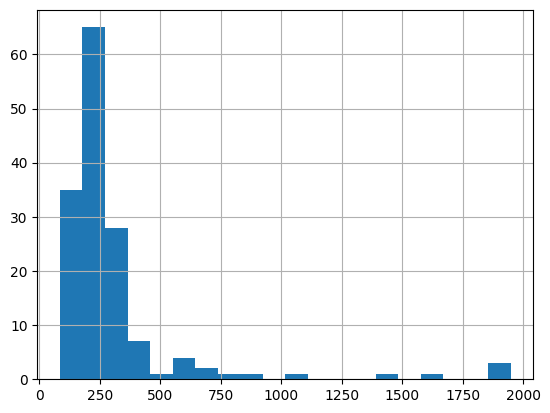

In [862]:
games['compra'].hist(bins=20)

Median imputation is the most appropriate choice here.

In [863]:
games_M_encuesta['compra'] = games_M_encuesta['compra'].fillna(games_M_encuesta['compra'].median())

In [ ]:
null_percentage(games_M_encuesta)

id              0.0
edad            0.0
genero          0.0
encuesta        0.0
satisfaccion    0.0
compra          0.0
dtype: float64

**Dropping a variable**

Items is removed because it has too many missing values to impute reliably.

Already removed.

In [ ]:
null_percentage(games_M_encuesta)

id              0.0
edad            0.0
genero          0.0
encuesta        0.0
satisfaccion    0.0
compra          0.0
dtype: float64

### 3. Guided Example: Elite Properties Missing Data

A real-estate dataset is used to decide which missing values should be removed and which can be imputed.

**Records:** 7,559 houses.

**Variables:** area, address, postal code, date, price, rooms, distance, bathrooms, cars, land size, building size, and construction year.

In [866]:
houses = pd.read_csv('houses_data.csv')
houses.head()

,Area,Direccion,CodigoPostal,Fecha,Precio,Habitaciones,Distacia,Banos,Carros,Terreno,Construccion,AnoConstriccion
0,Yarra,25 Bloomburg St,3067,11/1/2024,1035000.0,2,2.5,1,0.0,156,79.0,NaN
1,Yarra,5 Charles St,3067,10/1/2024,1465000.0,3,2.5,2,0.0,134,150.0,NaN
2,Yarra,55a Park St,3067,12/1/2024,1600000.0,4,2.5,1,2.0,120,142.0,2014.0
3,Yarra,124 Yarra St,3067,NaN,1876000.0,3,2.5,2,0.0,245,210.0,NaN
4,Yarra,98 Charles St,3067,12/1/2024,1636000.0,2,2.5,1,2.0,256,107.0,NaN


In [867]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7559 entries, 0 to 7558
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             6856 non-null   object 
 1   Direccion        7559 non-null   object 
 2   CodigoPostal     7559 non-null   int64  
 3   Fecha            6520 non-null   object 
 4   Precio           6830 non-null   float64
 5   Habitaciones     7559 non-null   int64  
 6   Distacia         7559 non-null   float64
 7   Banos            7559 non-null   int64  
 8   Carros           7527 non-null   float64
 9   Terreno          7559 non-null   int64  
 10  Construccion     7129 non-null   float64
 11  AnoConstriccion  5074 non-null   float64
dtypes: float64(5), int64(4), object(3)
memory usage: 708.8+ KB


In [ ]:
null_percentage(houses)

Area               0.093002
Direccion          0.000000
CodigoPostal       0.000000
Fecha              0.137452
Precio             0.096441
Habitaciones       0.000000
Distacia           0.000000
Banos              0.000000
Carros             0.004233
Terreno            0.000000
Construccion       0.056886
AnoConstriccion    0.328747
dtype: float64

In [869]:
#missingno.bar(houses, color="#7393B3", sort="ascending", figsize=(5,3), fontsize=9);

In [ ]:
null_percentage(houses)

Area               0.093002
Direccion          0.000000
CodigoPostal       0.000000
Fecha              0.137452
Precio             0.096441
Habitaciones       0.000000
Distacia           0.000000
Banos              0.000000
Carros             0.004233
Terreno            0.000000
Construccion       0.056886
AnoConstriccion    0.328747
dtype: float64

We first review the missing values:

- Area, date, price, cars, building size, and construction year all contain missing values.

Area and price are essential for the investment analysis, so rows missing either value are removed.

In [871]:
houses = houses.dropna(subset=['Area','Precio'])

The dataset shrinks after removing rows with missing values in those columns.

In [ ]:
null_percentage(houses)

Area               0.000000
Direccion          0.000000
CodigoPostal       0.000000
Fecha              0.139324
Precio             0.000000
Habitaciones       0.000000
Distacia           0.000000
Banos              0.000000
Carros             0.000000
Terreno            0.000000
Construccion       0.058833
AnoConstriccion    0.335866
dtype: float64

In [873]:
houses.isna().sum()/len(houses)

Area               0.000000
Direccion          0.000000
CodigoPostal       0.000000
Fecha              0.139324
Precio             0.000000
Habitaciones       0.000000
Distacia           0.000000
Banos              0.000000
Carros             0.000000
Terreno            0.000000
Construccion       0.058833
AnoConstriccion    0.335866
dtype: float64

We review the remaining missing values again:

- Removing rows with missing area and price values reduces the dataset from 7,559 to 6,187 rows.
- The cars variable no longer has missing values after the previous duplicate removal step.

- Date: 862 of 6,187 records (13.9%).
- Building size: 364 of 6,186 records (5.9%).
- Construction year: 2,087 of 6,187 records (33.6%).

The date variable shows when the property was listed in the last quarter of 2024, so it is not needed for the analysis and is removed.

Construction year can be useful, but the missing share is too high for a reliable imputation, so it is removed as well.

In [874]:
houses = houses.drop(columns=['Fecha', 'AnoConstriccion'])
houses.head()

,Area,Direccion,CodigoPostal,Precio,Habitaciones,Distacia,Banos,Carros,Terreno,Construccion
0,Yarra,25 Bloomburg St,3067,1035000.0,2,2.5,1,0.0,156,79.0
1,Yarra,5 Charles St,3067,1465000.0,3,2.5,2,0.0,134,150.0
2,Yarra,55a Park St,3067,1600000.0,4,2.5,1,2.0,120,142.0
3,Yarra,124 Yarra St,3067,1876000.0,3,2.5,2,0.0,245,210.0
4,Yarra,98 Charles St,3067,1636000.0,2,2.5,1,2.0,256,107.0


**Building size** contains a small share of missing values and remains relevant, so it is imputed.

We check the distribution before imputing.
- Normal distribution: mean imputation.
- Non-normal distribution: median imputation.

In [875]:
houses['Construccion'].skew()

np.float64(2.730084146613284)

<Axes: >

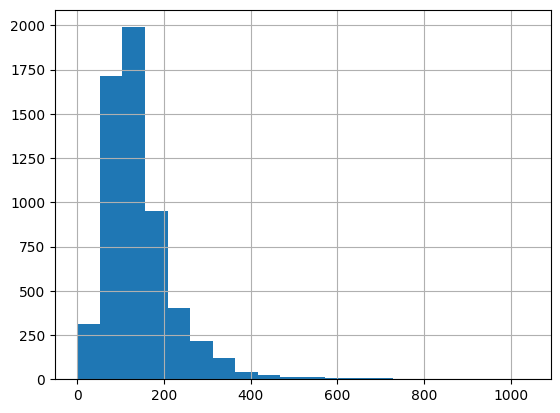

In [876]:
houses['Construccion'].hist(bins=20)

In [877]:
houses.fillna({'Construccion': houses['Construccion'].median()}, inplace=True)

### 4. Duplicate Data

Duplicate records can appear during data entry or data merging and should be reviewed carefully.

Common sources include human error and repeated identifiers with different values in other fields.

In [ ]:
games_dup = pd.read_csv('videogames_data.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'data/videogames_data_dup.csv'

**Exact duplicates**

In [ ]:
games_dup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            126 non-null    int64  
 1   edad          126 non-null    float64
 2   genero        126 non-null    object 
 3   encuesta      126 non-null    int64  
 4   satisfaccion  126 non-null    int64  
 5   compra        126 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 6.0+ KB


In [ ]:
games_dup.duplicated().sum()

17

In [ ]:
games_dup[games_dup.duplicated()]

,id,edad,genero,encuesta,satisfaccion,compra
105,1,25.5,Hombre,1,2,206.3
106,2,40.0,Hombre,1,5,297.9
107,3,30.0,Hombre,1,3,273.4
108,4,29.5,Mujer,1,5,327.6
109,8,34.5,Hombre,1,3,152.6
110,9,36.5,Mujer,1,5,276.5
111,12,35.0,Mujer,1,1,93.1
112,13,32.0,Hombre,1,5,136.3
113,17,28.5,Mujer,1,3,204.8
114,19,36.5,Mujer,1,5,337.7


In [ ]:
games_dup[games_dup['id']==1]

,id,edad,genero,encuesta,satisfaccion,compra
0,1,25.5,Hombre,1,2,206.3
105,1,25.5,Hombre,1,2,206.3


We checked with the company and confirmed that exactly 17 customers answered the survey twice. Therefore, we can **remove the duplicate records**.

In [ ]:
# Keep the first record
games_dup.drop_duplicates(inplace=True)

In [ ]:
# Check duplicates
games_dup.duplicated().sum()

0

**Records with some matching values**

For this dataset, there should be one record per customer, so we check whether duplicate IDs remain.

In [ ]:
games_dup[games_dup.duplicated(subset=['id'])]

,id,edad,genero,encuesta,satisfaccion,compra
122,120,29.0,Hombre,1,2,768.5
123,123,40.5,Hombre,1,3,456.8
124,125,35.0,Hombre,1,4,190.5
125,126,35.5,Hombre,1,2,867.5


In [ ]:
games_dup[games_dup['id'].isin([120,123,125,126])]

,id,edad,genero,encuesta,satisfaccion,compra
55,120,29.0,Hombre,1,2,162.7
56,123,40.5,Hombre,1,3,207.1
57,125,35.0,Hombre,1,4,156.9
58,126,35.5,Hombre,1,2,181.7
122,120,29.0,Hombre,1,2,768.5
123,123,40.5,Hombre,1,3,456.8
124,125,35.0,Hombre,1,4,190.5
125,126,35.5,Hombre,1,2,867.5


Four duplicated customer IDs are found, and the purchase amount differs across the repeated records.

Because the reason is unknown, we do not decide which row to keep and instead question the data quality.

### 5. Conclusion

Missing and duplicate data need different treatments depending on the context, the amount of missingness, and the risk of bias.

The goal is to preserve data quality without changing the analysis process more than necessary.